# Experiment: Draw Generated Data

Objective:
- Read `loc_data_kuramoto/generated_data.npz` inside this project.
- Inspect the array keys and shapes before plotting.
- Visualize the generated Kuramoto data in a notebook that is easy to debug cell by cell.


In [1]:
from __future__ import annotations

from pathlib import Path
from typing import Dict, List, Optional, Tuple, Union

import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
from scipy.signal import hilbert
from IPython.display import display

project_root = Path.cwd()
if not (project_root / "loc_data_kuramoto").exists():
    candidate = project_root / "causal_network_mix_2_0.2_syn2_theta"
    if candidate.exists():
        project_root = candidate
npz_path = project_root / "loc_data_kuramoto" / "generated_data.npz"
output_path = project_root / "loc_data_kuramoto" / "generated_data_overview.png"

print(f"project_root: {project_root}")
print(f"npz_path: {npz_path}")
print(f"output_path: {output_path}")
print(f"npz exists: {npz_path.exists()}")

project_root: /home/wangzhipeng/code/causal_network/causal_network/lorzen/causal_network_mlp_tanh
npz_path: /home/wangzhipeng/code/causal_network/causal_network/lorzen/causal_network_mlp_tanh/loc_data_kuramoto/generated_data.npz
output_path: /home/wangzhipeng/code/causal_network/causal_network/lorzen/causal_network_mlp_tanh/loc_data_kuramoto/generated_data_overview.png
npz exists: True


## Plan

- Step 1: load every array stored in the `.npz` archive.
- Step 2: inspect keys, shapes, and dtypes to confirm what will be plotted.
- Step 3: draw one overview figure with data traces, coupling matrix, and natural frequencies.


In [2]:
def load_npz_archive(path: Union[str, Path]) -> Dict[str, np.ndarray]:
    path = Path(path)
    if not path.exists():
        raise FileNotFoundError(f"npz file not found: {path}")

    with np.load(path, allow_pickle=False) as archive:
        keys = list(archive.keys())
        if not keys:
            raise ValueError(f"No arrays found in npz file: {path}")
        return {key: np.asarray(archive[key]) for key in keys}


def summarize_archive(archive: Dict[str, np.ndarray]) -> Dict[str, Dict[str, object]]:
    return {
        key: {
            "shape": tuple(value.shape),
            "dtype": str(value.dtype),
        }
        for key, value in archive.items()
    }


In [3]:
archive = load_npz_archive(npz_path)
summary = summarize_archive(archive)
display(summary)

data = archive["data"]
print("data shape:", data.shape)
print("first 5 values of series 0, step 0:", data[0, 0, :5])


{'data': {'shape': (1, 10001, 32), 'dtype': 'float32'},
 'obj_matrix': {'shape': (32, 32), 'dtype': 'float32'},
 'group_matrix': {'shape': (32, 2), 'dtype': 'float32'},
 'omegas': {'shape': (32,), 'dtype': 'float32'},
 'theta_data': {'shape': (1, 10001, 32), 'dtype': 'float32'},
 'series_lengths': {'shape': (1,), 'dtype': 'int32'}}

data shape: (1, 10001, 32)
first 5 values of series 0, step 0: [-1.7804818 -1.7540814 -1.7042853 -1.7307844 -1.7299482]


In [4]:
archive["theta_data"].shape

(1, 10001, 32)

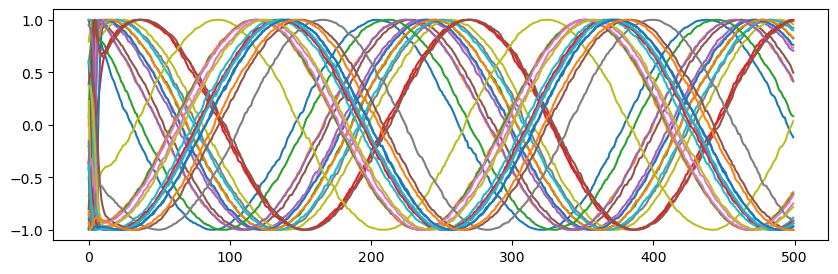

In [5]:
plt.figure(figsize=(10,3))
plt.plot(np.sin(archive["theta_data"][0][:,:16])[:500])
plt.plot(np.sin(archive["theta_data"][0][:,16:])[:500])

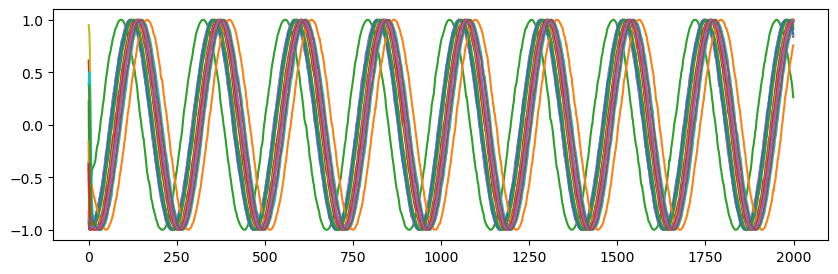

In [6]:
plt.figure(figsize=(10,3))
# plt.plot(np.sin(archive["theta_data"][0][:,:16])[:2000])
plt.plot(np.sin(archive["theta_data"][0][:,16:])[:2000])

In [7]:
def infer_theta_series_from_archive(
    archive: Dict[str, np.ndarray],
    data: np.ndarray,
) -> Tuple[Optional[np.ndarray], Optional[np.ndarray], Optional[str]]:
    if "group_matrix" not in archive:
        return None, None, None

    group_matrix = np.asarray(archive["group_matrix"], dtype=np.float32)
    if group_matrix.ndim != 2:
        return None, None, None

    oscillator_count = int(group_matrix.shape[0])

    if "theta_data" in archive:
        theta_series = np.asarray(archive["theta_data"], dtype=np.float32)
        if theta_series.ndim == 2:
            theta_series = theta_series[None, ...]
        if theta_series.ndim == 3 and theta_series.shape[-1] == oscillator_count:
            return theta_series, group_matrix, "theta_data"



    feature_dim = int(data.shape[-1])
    if feature_dim >= oscillator_count * 2:
        paired = np.asarray(data[..., : oscillator_count * 2], dtype=np.float32)
        paired = paired.reshape(data.shape[0], data.shape[1], oscillator_count, 2)
        sin_values = paired[..., 0]
        cos_values = paired[..., 1]
        theta_series = np.unwrap(np.arctan2(sin_values, cos_values), axis=1)
        return theta_series, group_matrix, "atan2(sin, cos)"

    if feature_dim >= oscillator_count:
        sin_values = np.asarray(data[..., :oscillator_count], dtype=np.float32)
        analytic_signal = hilbert(sin_values, axis=1)
        theta_series = np.unwrap(np.angle(analytic_signal), axis=1)
        return theta_series, group_matrix, "hilbert(sin(theta))"

    return None, None, None


def get_group_oscillator_indices(group_matrix: np.ndarray) -> List[np.ndarray]:
    indices_per_group = []
    for group_idx in range(group_matrix.shape[1]):
        oscillator_indices = np.flatnonzero(group_matrix[:, group_idx] > 0.5)
        if len(oscillator_indices) > 0:
            indices_per_group.append(oscillator_indices)
    return indices_per_group


def get_group_feature_indices(
    oscillator_indices: np.ndarray,
    feature_dim: int,
    oscillator_count: int,
) -> List[int]:
    if feature_dim >= oscillator_count * 2:
        feature_indices = []
        for osc_idx in oscillator_indices:
            feature_indices.extend([2 * int(osc_idx), 2 * int(osc_idx) + 1])
        return feature_indices
    return [int(idx) for idx in oscillator_indices if int(idx) < feature_dim]


def build_feature_labels(feature_dim: int, oscillator_count: int) -> List[str]:
    if feature_dim >= oscillator_count * 2:
        labels = []
        for osc_idx in range(oscillator_count):
            labels.extend([f"sin_theta_{osc_idx}", f"cos_theta_{osc_idx}"])
        if feature_dim > oscillator_count * 2:
            labels.extend([f"feature_{idx}" for idx in range(oscillator_count * 2, feature_dim)])
        return labels[:feature_dim]
    return [f"feature_{idx}" for idx in range(feature_dim)]


def compute_order_parameter_curves(
    theta_series: np.ndarray,
    group_matrix: np.ndarray,
) -> Tuple[np.ndarray, List[np.ndarray]]:
    global_r = np.abs(np.mean(np.exp(1j * theta_series), axis=1))

    group_curves = []
    for oscillator_indices in get_group_oscillator_indices(group_matrix):
        group_theta = theta_series[:, oscillator_indices]
        group_r = np.abs(np.mean(np.exp(1j * group_theta), axis=1))
        group_curves.append(group_r)
    
    return global_r, group_curves


def visualize_generated_npz(
    archive: Dict[str, np.ndarray],
    output_path: Optional[Union[str, Path]] = None,
    max_time_steps: int = 300,
    max_features: int = 16,
    max_lines: int = 6,
    series_index: int = 10,
):
    if "data" not in archive:
        raise ValueError("The archive must contain a 'data' array.")

    data = np.asarray(archive["data"], dtype=np.float32)
    if data.ndim == 2:
        data = data[None, ...]
    if data.ndim != 3:
        raise ValueError(f"Expected 'data' to have 2 or 3 dimensions, but got shape {data.shape}")

    if not 0 <= int(series_index) < data.shape[0]:
        raise IndexError(f"series_index must be in [0, {data.shape[0] - 1}]")

    _, time_steps, feature_dim = data.shape
    show_time_steps = min(int(max_time_steps), time_steps)
    show_features = min(int(max_features), feature_dim)

    theta_series_all, group_matrix, order_parameter_mode = infer_theta_series_from_archive(archive, data)
    oscillator_count = None if group_matrix is None else int(group_matrix.shape[0])
    group_oscillator_indices = [] if group_matrix is None else get_group_oscillator_indices(group_matrix)
    feature_labels = build_feature_labels(feature_dim, oscillator_count or 0)
    group_count = max(len(group_oscillator_indices), 1)

    figure = plt.figure(figsize=(16, 4 * group_count + 8))
    grid = figure.add_gridspec(group_count + 2, 2, height_ratios=[1.1] * group_count + [1.0, 1.0])
    group_axes = [figure.add_subplot(grid[group_idx, :]) for group_idx in range(group_count)]
    global_order_axis = figure.add_subplot(grid[group_count, 0])
    group_order_axis = figure.add_subplot(grid[group_count, 1])
    matrix_axis = figure.add_subplot(grid[group_count + 1, 0])
    omega_axis = figure.add_subplot(grid[group_count + 1, 1])

    time_axis = np.arange(show_time_steps)
    series = data[int(series_index), :show_time_steps]
    if group_matrix is not None and group_oscillator_indices:
        for group_idx, (axis, oscillator_indices) in enumerate(zip(group_axes, group_oscillator_indices)):
            feature_indices = get_group_feature_indices(oscillator_indices, feature_dim, oscillator_count)
            feature_indices = feature_indices[: int(max_lines)]
            for feature_index in feature_indices:
                axis.plot(
                    time_axis,
                    series[:, feature_index],
                    linewidth=1.1,
                    alpha=0.85,
                    label=feature_labels[feature_index],
                )
            axis.set_title(f"Group {group_idx} Output Data Time Series (series {series_index})")
            axis.set_ylabel("Value")
            axis.grid(alpha=0.25)
            if feature_indices:
                axis.legend(bbox_to_anchor=(1.02, 1), loc="upper left", ncol=1, fontsize=8)
        group_axes[-1].set_xlabel("Time Step")
    else:
        for feature_index in range(min(int(max_lines), show_features)):
            group_axes[0].plot(
                time_axis,
                series[:, feature_index],
                linewidth=1.2,
                alpha=0.85,
                label=feature_labels[feature_index],
            )
        group_axes[0].set_title(f"Series {series_index} Traces ({min(int(max_lines), show_features)} features)")
        group_axes[0].set_xlabel("Time Step")
        group_axes[0].set_ylabel("Value")
        group_axes[0].grid(alpha=0.25)
        if min(int(max_lines), show_features) > 0:
            group_axes[0].legend(bbox_to_anchor=(1.02, 1), loc="upper left", ncol=1, fontsize=8)

    if theta_series_all is not None and group_matrix is not None:
        theta_series = theta_series_all[int(series_index), :show_time_steps]
        global_r, group_curves = compute_order_parameter_curves(theta_series, group_matrix)

        global_order_axis.plot(time_axis, global_r, color="black", linewidth=2)
        global_order_axis.set_title("Global Order Parameter R(t)")
        global_order_axis.set_xlabel("Time Step")
        global_order_axis.set_ylabel("R(t)")
        global_order_axis.set_ylim(0, 1.05)
        global_order_axis.grid(alpha=0.25)

        for group_idx, group_r in enumerate(group_curves):
            group_order_axis.plot(
                time_axis,
                group_r,
                linewidth=1.8,
                alpha=0.9,
                label=f"Group {group_idx}",
            )
        group_order_axis.set_title("Group-wise Order Parameters R_g(t)")
        group_order_axis.set_xlabel("Time Step")
        group_order_axis.set_ylabel("R_g(t)")
        group_order_axis.set_ylim(0, 1.05)
        group_order_axis.grid(alpha=0.25)
        if group_curves:
            group_order_axis.legend(loc="upper right")
    else:
        for axis, title in [
            (global_order_axis, "Global Order Parameter R(t)"),
            (group_order_axis, "Group-wise Order Parameters R_g(t)"),
        ]:
            axis.set_title(title)
            axis.axis("off")
            axis.text(
                0.5,
                0.5,
                "Order parameters unavailable\n(requires Kuramoto phase observations)",
                ha="center",
                va="center",
                fontsize=10,
            )

    if "obj_matrix" in archive:
        obj_matrix = np.asarray(archive["obj_matrix"], dtype=np.float32)
        sns.heatmap(obj_matrix, ax=matrix_axis, cmap="YlOrRd", square=True, cbar=True)
        matrix_axis.set_title("obj_matrix Heatmap")
        matrix_axis.set_xlabel("Oscillator Index")
        matrix_axis.set_ylabel("Oscillator Index")
    else:
        matrix_axis.hist(data.reshape(-1), bins=60, color="#2563EB", alpha=0.85)
        matrix_axis.set_title("Data Value Distribution")
        matrix_axis.set_xlabel("Value")
        matrix_axis.set_ylabel("Count")

    if "omegas" in archive:
        omegas = np.asarray(archive["omegas"], dtype=np.float32)
        group_ids = None
        if group_matrix is not None and group_matrix.shape[0] == omegas.shape[0]:
            group_ids = np.argmax(group_matrix, axis=1)

        indices = np.arange(len(omegas))
        if group_ids is None:
            omega_axis.bar(indices, omegas, color="#D97706", alpha=0.9)
        else:
            cmap = plt.cm.get_cmap("tab10", int(group_ids.max()) + 1)
            colors = [cmap(int(group_id)) for group_id in group_ids]
            omega_axis.bar(indices, omegas, color=colors, alpha=0.9)
        omega_axis.set_title(f"Natural Frequencies per Oscillator (len(omegas)={len(omegas)})")
        omega_axis.set_xlabel("Oscillator Index")
        omega_axis.set_ylabel("Omega")
        omega_axis.text(
            0.98,
            0.95,
            f"len(omegas) = {len(omegas)}",
            transform=omega_axis.transAxes,
            ha="right",
            va="top",
            fontsize=9,
            bbox={"boxstyle": "round,pad=0.25", "facecolor": "white", "alpha": 0.85, "edgecolor": "#D1D5DB"},
        )
    else:
        flat_means = data.mean(axis=(0, 1))
        omega_axis.bar(
            np.arange(len(flat_means[:show_features])),
            flat_means[:show_features],
            color="#D97706",
            alpha=0.9,
        )
        omega_axis.set_title("Mean Value Per Feature")
        omega_axis.set_xlabel("Feature")
        omega_axis.set_ylabel("Mean")

    figure.tight_layout(rect=(0, 0, 1, 0.98))

    saved_path = None
    if output_path is not None:
        output_path = Path(output_path)
        output_path.parent.mkdir(parents=True, exist_ok=True)
        figure.savefig(output_path, dpi=200, bbox_inches="tight")
        saved_path = str(output_path.resolve())

    result = {
        "keys": tuple(archive.keys()),
        "data_shape": tuple(data.shape),
        "saved_path": saved_path,
        "order_parameter_mode": order_parameter_mode,
        "series_index": int(series_index),
        "group_count": len(group_oscillator_indices),
    }
    return figure, result

/tmp/ipykernel_406269/452205723.py:227: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = plt.cm.get_cmap("tab10", int(group_ids.max()) + 1)


{'keys': ('data',
  'obj_matrix',
  'group_matrix',
  'omegas',
  'theta_data',
  'series_lengths'),
 'data_shape': (1, 10001, 32),
 'saved_path': '/home/wangzhipeng/code/causal_network/causal_network/lorzen/causal_network_mlp_tanh/loc_data_kuramoto/generated_data_overview.png',
 'order_parameter_mode': 'theta_data',
 'series_index': 0,
 'group_count': 2}

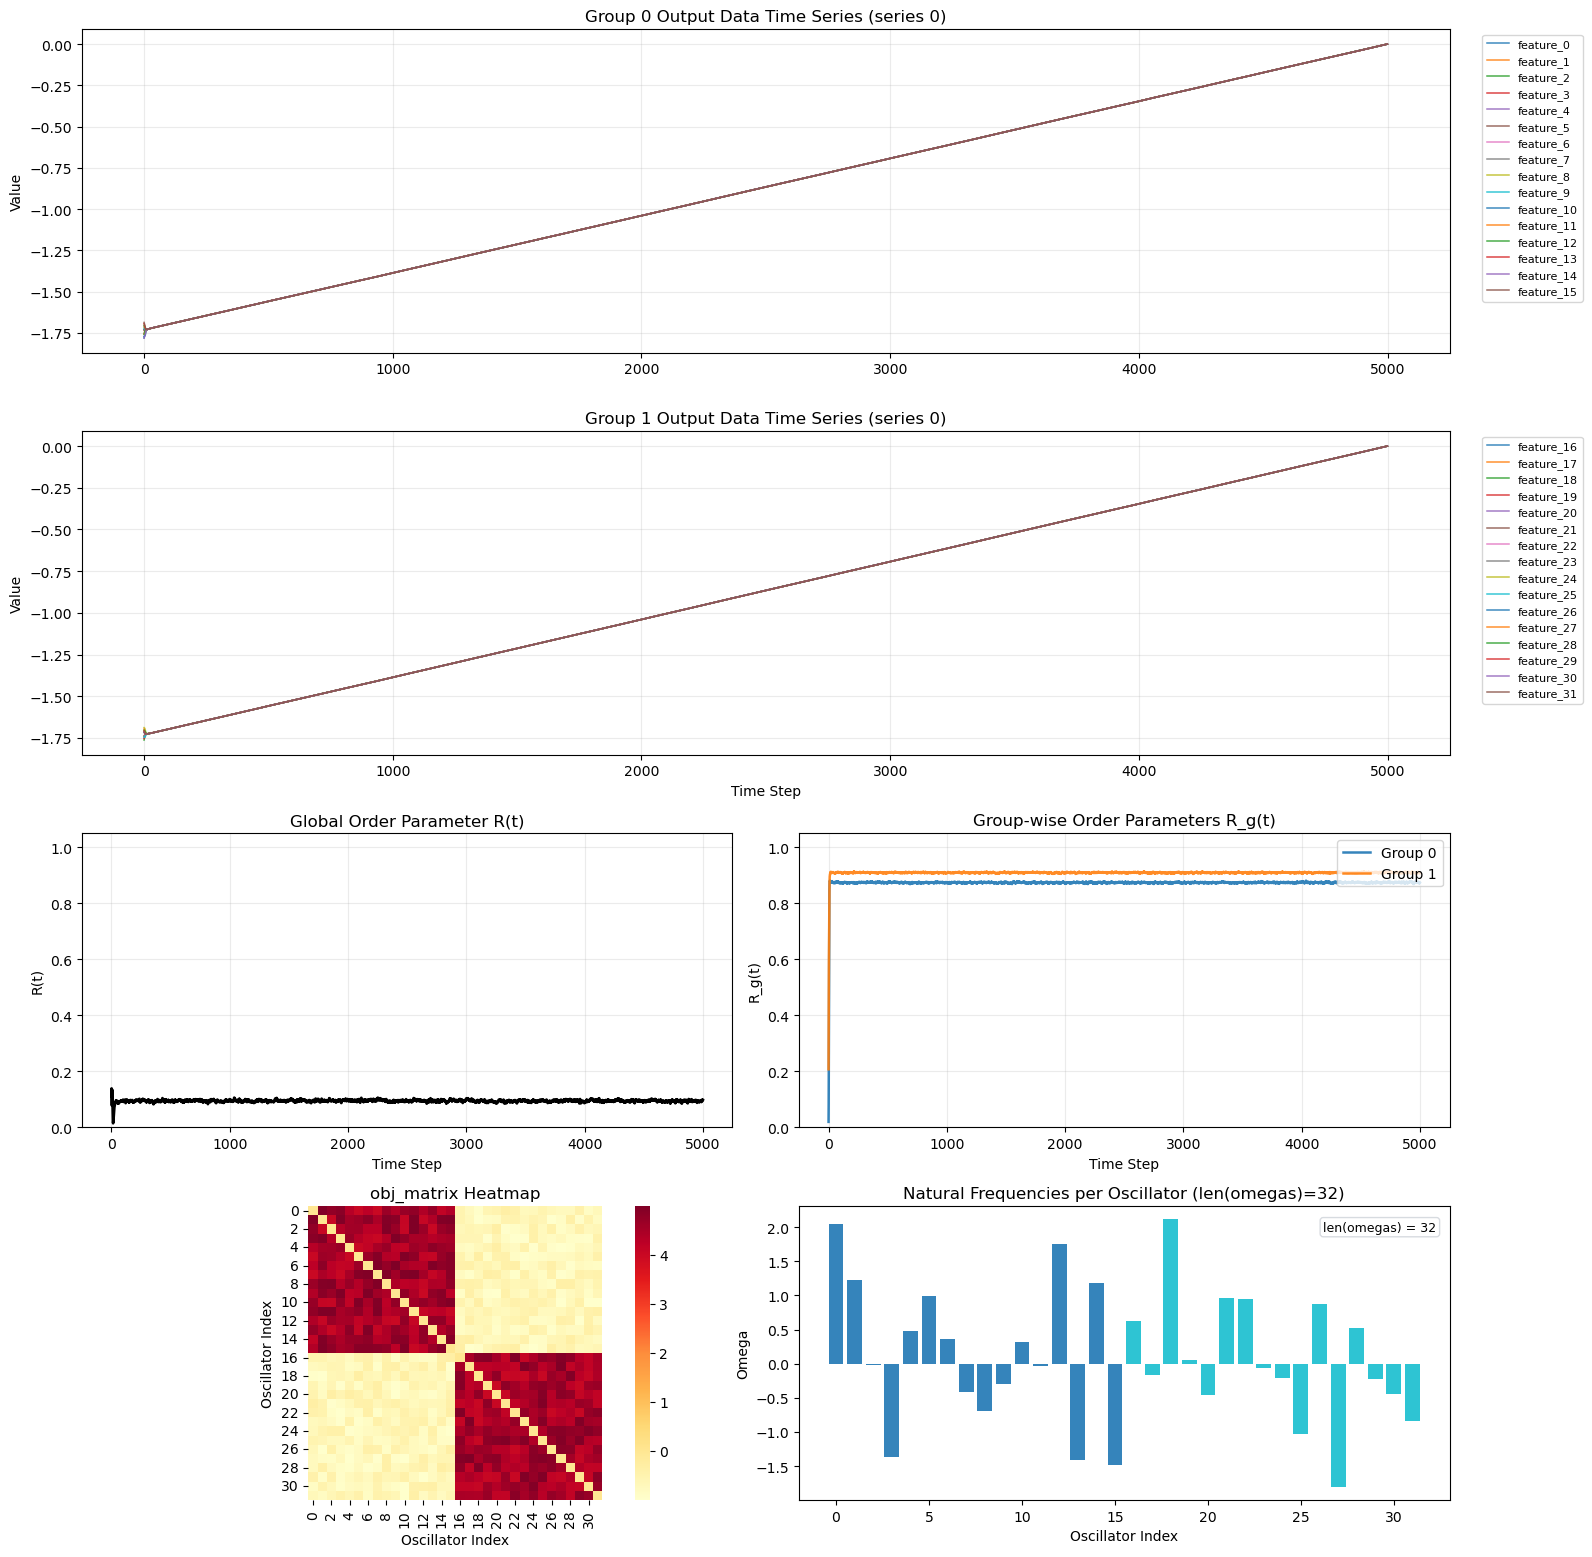

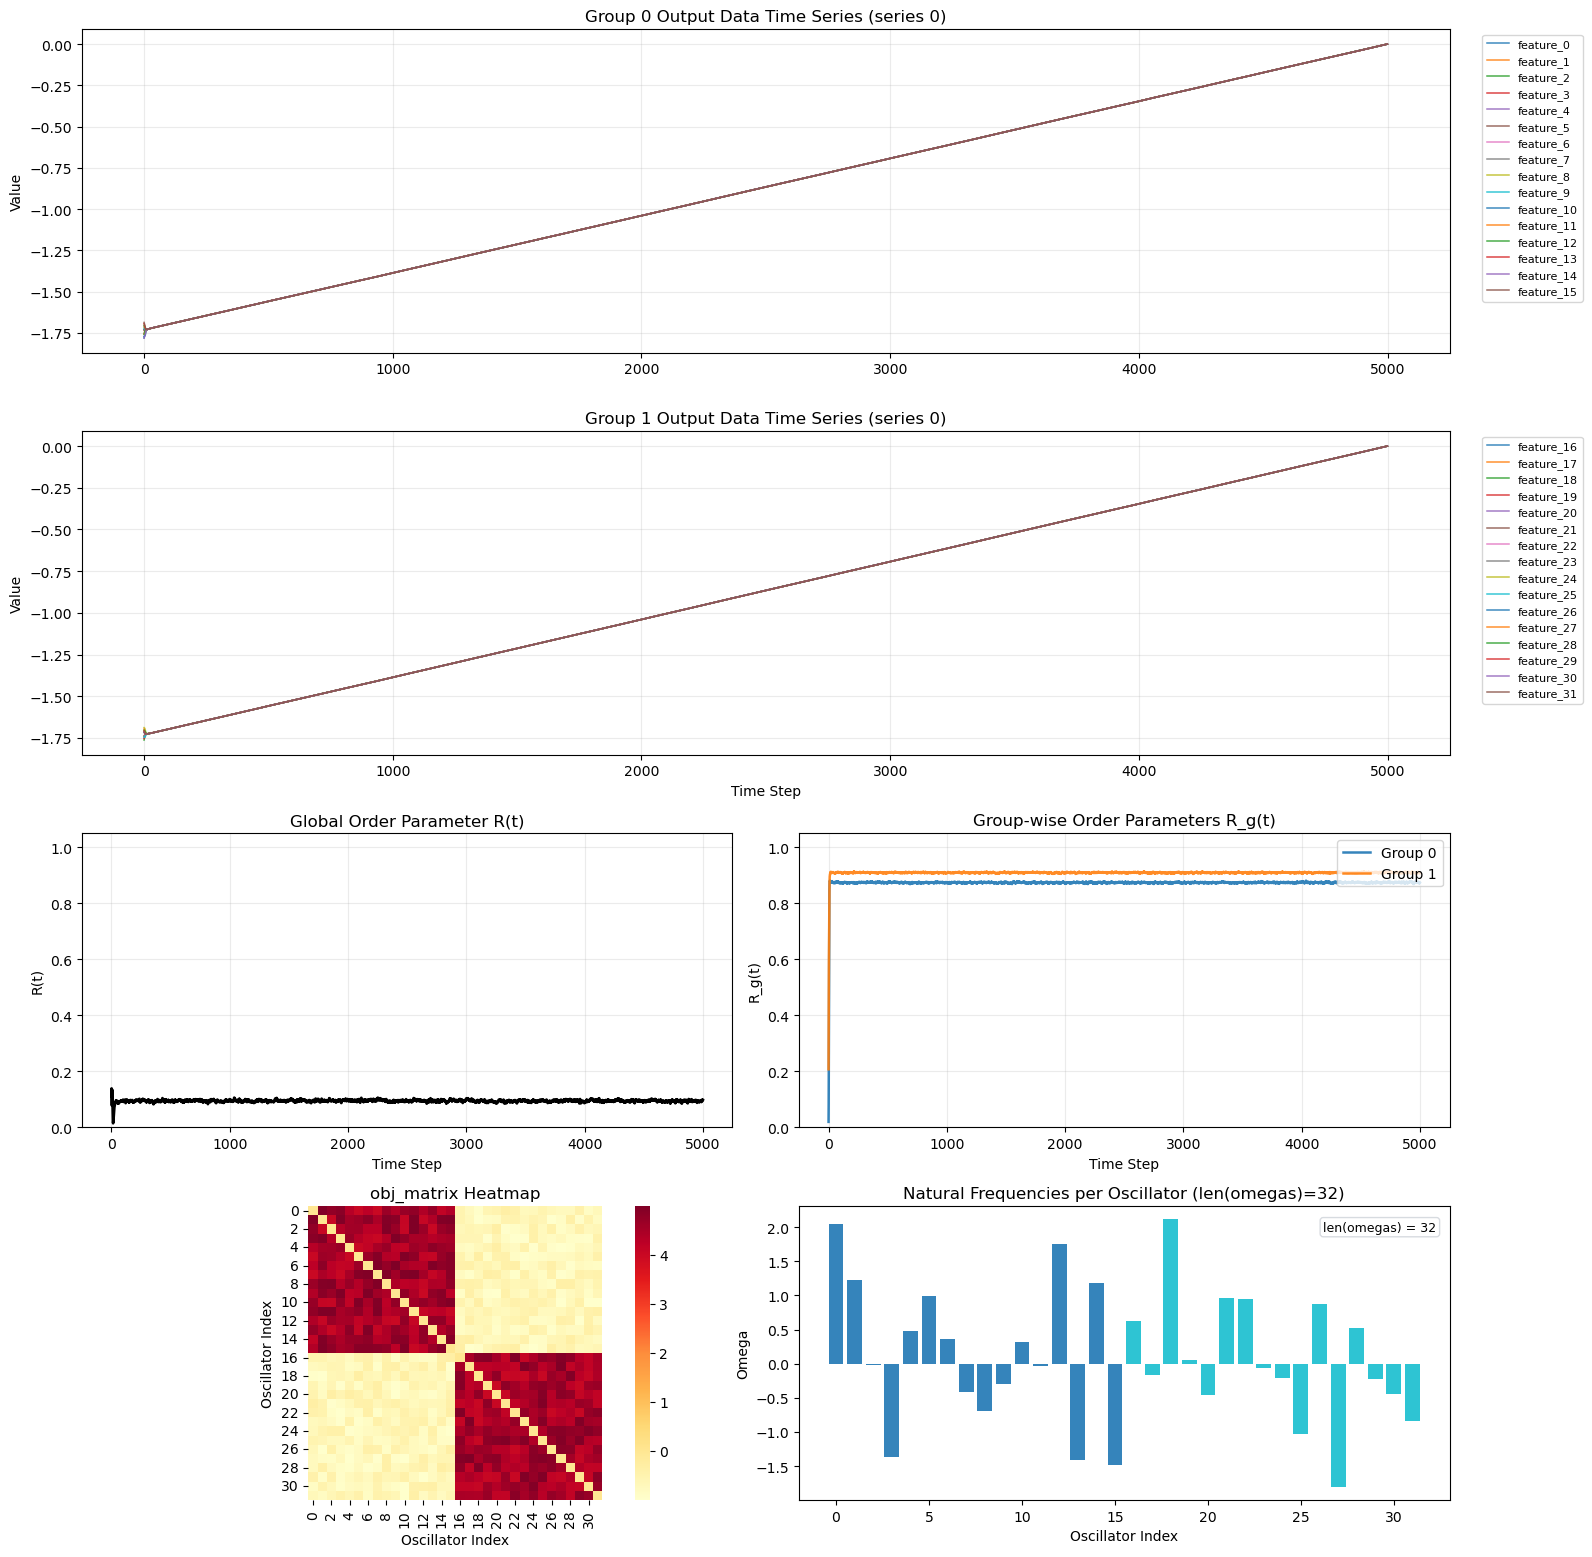

In [ ]:
figure, result = visualize_generated_npz(
    archive,
    output_path=output_path,
    max_time_steps=5000,
    max_features=32,
    max_lines=32,
    series_index= 0
)
display(result)
figure